# ⚡ Energy Lab — Partie 3 : la maison complète

Dans la Partie 1, on avait un seul appareil (le frigo) et deux états bien séparés :
moyenne et écart-type suffisaient. Dans la Partie 2, on a vu que le **rythme** du frigo
lui-même (FFT, ondelettes) révèle des informations invisibles à la moyenne.

Ici, le compteur Linky mesure **la somme** de tout ce qui est branché :
frigo + lave-linge + micro-ondes + cuit-vapeur, tous en même temps.
Le défi : retrouver chaque appareil dans ce signal agrégé, en combinant les outils
des deux parties précédentes.

**Ce qu'on va apprendre :**
1. Détecter des évènements dans un signal agrégé (fronts de puissance)
2. Comprendre pourquoi une seule feature ne suffit plus
3. Combiner les features (stats, FFT, duty cycle) dans un vecteur unique
4. Comparer deux méthodes de classification : Random Forest et DTW

> `Shift+Enter` pour exécuter une cellule. Dans les exercices, cherche
> **avant** de lire la cellule de correction qui suit.

In [8]:
import random as _random_qcm
import ipywidgets as w
from IPython.display import display

_RELANCES_HUMOUR = [
    "Le compresseur du frigo a plus de constance que cette réponse.",
    "Pas grave, même le capteur Linky se trompe parfois (façon de parler).",
    "On va dire que c'était un test de tes réflexes, pas de tes connaissances.",
    "Presque ! Enfin... pas vraiment, mais l'intention y était.",
    "Le lave-linge fait plus de bruit que cette hypothèse, mais il a raison.",
    "Retente ta chance, la maison ne t'en voudra pas.",
]

def qcm(question, options, correct, explication=""):
    """
    Affiche un QCM interactif.
    correct : index (int) ou liste d'index de la/des bonne(s) réponse(s).
    """
    if isinstance(correct, int):
        correct = [correct]

    boutons = w.RadioButtons(options=options, layout=w.Layout(width='100%'))
    sortie  = w.Output()
    titre   = w.HTML(f"<b>❓ {question}</b>")

    def verifier(change):
        idx = options.index(change['new'])
        sortie.clear_output()
        with sortie:
            if idx in correct:
                display(w.HTML(
                    f"<div style='padding:8px;border-radius:6px;background:#d4edda;color:#155724'>"
                    f"✅ <b>Correct !</b> {explication}</div>"
                ))
            else:
                humour = _random_qcm.choice(_RELANCES_HUMOUR)
                display(w.HTML(
                    f"<div style='padding:8px;border-radius:6px;background:#f8d7da;color:#721c24'>"
                    f"❌ <b>Pas tout à fait.</b> {humour}<br>"
                    f"<b>Pourquoi ce n'est pas ça :</b> {explication}</div>"
                ))

    boutons.observe(verifier, names='value')
    display(w.VBox([titre, boutons, sortie]))


def check(nom, valeur, attendu, tol=1e-6):
    """
    Vérifie la valeur d'une variable calculée dans un exercice, et affiche
    un feedback stylé (comme qcm(), mais pour du code plutôt qu'un choix).
    """
    try:
        if isinstance(attendu, (int, float)) and isinstance(valeur, (int, float)):
            ok = abs(valeur - attendu) <= tol
        else:
            ok = valeur == attendu
    except Exception:
        ok = False

    if ok:
        display(w.HTML(
            f"<div style='padding:8px;border-radius:6px;background:#d4edda;color:#155724'>"
            f"✅ <b>{nom}</b> correct : {valeur}</div>"
        ))
    else:
        display(w.HTML(
            f"<div style='padding:8px;border-radius:6px;background:#f8d7da;color:#721c24'>"
            f"❌ <b>{nom}</b> incorrect. Ta valeur : {valeur} — attendu proche de {attendu}.</div>"
        ))
    return ok

print("✅ Fonctions qcm() et check() prêtes.")

✅ Fonctions qcm() et check() prêtes.


---
# Partie 3 — La maison complète

## 3.1 · Superposer plusieurs appareils

Le signal Linky est la **somme** des consommations individuelles :

```
signal_total = frigo + lave_linge + micro_ondes + cuit_vapeur + bruit
```

On reprend le générateur de frigo de la Partie 1/2, et on superpose trois
évènements sur une journée de 24h :

- **Lave-linge** vers 21h (~15 min) : chauffe de l'eau, puis lavage (oscillations),
  puis essorage (pic de puissance)
- **Micro-ondes** à 12h05 (~3 min) : puissance quasi constante
- **Cuit-vapeur** à 19h (~20 min) : cycles ON/OFF d'un thermostat

In [9]:
import random
import numpy as np

def generer_frigo(duree_on_s, duree_off_s, duree_totale_h=8,
                   puissance_on=150, puissance_off=30, bruit=8,
                   alea_duree=0.25, seed=42):
    """Génère un signal de frigo — même logique que la Partie 1/2, paramétrable."""
    rng = random.Random(seed)
    N = duree_totale_h * 3600 // 10
    signal = []
    i = 0
    en_on = True
    duree_restante = round(duree_on_s * rng.uniform(1 - alea_duree, 1 + alea_duree)) // 10
    while i < N:
        if duree_restante <= 0:
            en_on = not en_on
            base = duree_on_s if en_on else duree_off_s
            duree_restante = round(base * rng.uniform(1 - alea_duree, 1 + alea_duree)) // 10
        p = puissance_on if en_on else puissance_off
        p += rng.gauss(0, bruit)
        signal.append(max(0, p))
        duree_restante -= 1
        i += 1
    return np.array(signal)


def profil_micro_ondes(duree_min=3, dt=10, seed=0, jitter=0.1, puissance=900):
    """Micro-ondes : puissance quasi constante pendant toute la durée."""
    rng = random.Random(seed)
    duree = duree_min * rng.uniform(1 - jitter, 1 + jitter)
    n = max(3, int(duree * 60 / dt))
    bruit = np.array([rng.gauss(0, 15) for _ in range(n)])
    return np.maximum(0, puissance + bruit)


def profil_cuit_vapeur(duree_min=20, dt=10, seed=0, jitter=0.1,
                        puissance_on=1325, puissance_off=50,
                        cycle_on_s=120, cycle_off_s=60):
    """Cuit-vapeur : thermostat qui cycle ON/OFF autour d'une consigne.
    puissance_on=1325 avec un duty cycle théorique de 2/3 (120s/180s) donne une
    moyenne pondérée ≈ 900 W, comparable au micro-ondes malgré une forme très différente."""
    rng = random.Random(seed)
    duree = duree_min * rng.uniform(1 - jitter, 1 + jitter)
    n = max(6, int(duree * 60 / dt))
    profil = np.zeros(n)
    i = 0
    en_on = True
    reste = cycle_on_s // dt
    while i < n:
        if reste <= 0:
            en_on = not en_on
            reste = (cycle_on_s if en_on else cycle_off_s) // dt
        profil[i] = puissance_on if en_on else puissance_off
        reste -= 1
        i += 1
    bruit = np.array([rng.gauss(0, 15) for _ in range(n)])
    return np.maximum(0, profil + bruit)


def profil_lave_linge(duree_min=15, dt=10, seed=0, jitter=0.15):
    """Lave-linge simplifié : chauffe (25%), lavage oscillant (50%), essorage (25%)."""
    rng = random.Random(seed)
    duree = duree_min * rng.uniform(1 - jitter, 1 + jitter)
    n = max(9, int(duree * 60 / dt))
    profil = np.zeros(n)
    i1 = int(n * 0.25)
    i2 = int(n * 0.75)
    profil[:i1] = 2000
    profil[i1:i2] = 400 + 250 * np.sin(np.linspace(0, 6 * np.pi, i2 - i1))
    profil[i2:] = 2500
    bruit = np.array([rng.gauss(0, 20) for _ in range(n)])
    return np.maximum(0, profil + bruit)


def construire_journee():
    """Une journée de 24h : frigo en continu + 3 évènements ponctuels."""
    frigo = generer_frigo(10 * 60, 20 * 60, duree_totale_h=24, seed=42)
    n = len(frigo)
    heures = np.arange(n) * 10 / 3600
    total = frigo.copy()
    tags = np.array([''] * n, dtype=object)

    def inserer(profil, heure_debut, tag):
        i0 = int(heure_debut * 3600 / 10)
        i1 = min(n, i0 + len(profil))
        total[i0:i1] += profil[: i1 - i0]
        tags[i0:i1] = tag
        return i0, i1

    inserer(profil_micro_ondes(seed=1), 12 + 5 / 60, 'micro_ondes')
    inserer(profil_cuit_vapeur(seed=2), 19, 'cuit_vapeur')
    inserer(profil_lave_linge(seed=3), 21, 'lave_linge')

    return heures, total, tags

heures_jour, signal_total, tags_jour = construire_journee()
print(f"{len(signal_total)} points sur 24h")
for tag in ['micro_ondes', 'cuit_vapeur', 'lave_linge']:
    n_pts = (tags_jour == tag).sum()
    print(f"  {tag:12s} : {n_pts} points ({n_pts * 10 / 60:.0f} min)")

8640 points sur 24h
  micro_ondes  : 16 points (3 min)
  cuit_vapeur  : 130 points (22 min)
  lave_linge   : 82 points (14 min)


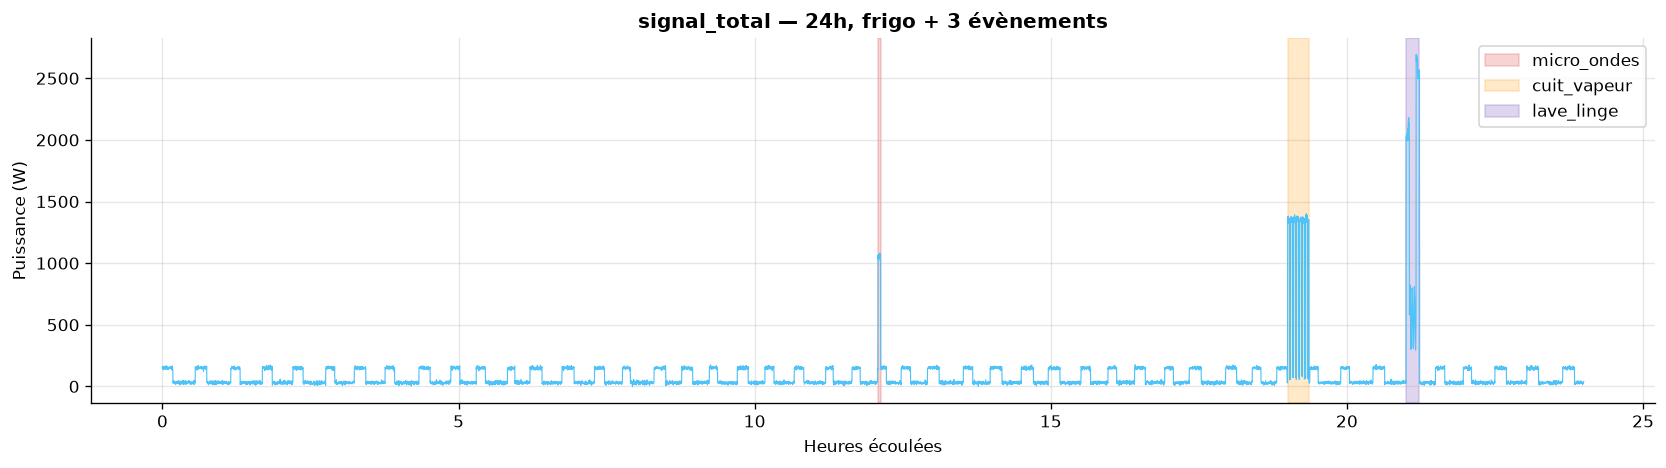

Les cycles réguliers et discrets du frigo (30-170 W) sont écrasés à l'échelle
des évènements ponctuels (jusqu'à 2500 W) : c'est bien une somme.


In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

couleurs_tag = {'micro_ondes': '#e57373', 'cuit_vapeur': '#ffb74d', 'lave_linge': '#9575cd'}

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(heures_jour, signal_total, color='#4fc3f7', lw=0.7)
for tag, coul in couleurs_tag.items():
    mask = tags_jour == tag
    if mask.any():
        h0 = heures_jour[mask][0]
        h1 = heures_jour[mask][-1]
        ax.axvspan(h0, h1, color=coul, alpha=0.3, label=tag)
ax.set_xlabel('Heures écoulées')
ax.set_ylabel('Puissance (W)')
ax.set_title('signal_total — 24h, frigo + 3 évènements', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Les cycles réguliers et discrets du frigo (30-170 W) sont écrasés à l'échelle")
print("des évènements ponctuels (jusqu'à 2500 W) : c'est bien une somme.")

On a utilisé le module `windowing.py` de la Partie 1 pour découper le signal en
fenêtres fixes. Ici, on veut plutôt détecter automatiquement **où** se trouvent les
évènements dans `signal_total`, sans connaître leurs horaires à l'avance. C'est le rôle
de `windowing.slice_on_edges` : il détecte les sauts de puissance et découpe une
fenêtre autour de chaque saut.

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import windowing as W
import pandas as pd
from datetime import datetime, timedelta, timezone

t0 = datetime(2026, 7, 6, 0, 0, 0, tzinfo=timezone.utc)
timestamps = [(t0 + timedelta(seconds=i * 10)).strftime('%Y-%m-%dT%H:%M:%SZ') for i in range(len(signal_total))]
df_jour = pd.DataFrame({
    'timestamp': timestamps,
    'valeur_W':  signal_total.astype(float),
    'tag':       [t if t else None for t in tags_jour],
})

# Seuil de détection : bien au-dessus du saut du frigo seul (~120 W), pour ne
# déclencher que sur les vrais évènements, pas sur chaque cycle du compresseur.
fenetres_detectees = W.slice_on_edges(df_jour, threshold_W=300, pre_s=30, post_s=60)

comptes = pd.Series([f['tag'] for f in fenetres_detectees]).value_counts()
print(f"{len(fenetres_detectees)} fenêtres détectées par sauts de puissance :")
print(comptes.to_string())

22 fenêtres détectées par sauts de puissance :
cuit_vapeur    16
lave_linge      4
micro_ondes     2


In [12]:
qcm(
    "Le détecteur de fronts utilise un seuil de 300 W. Pourquoi ce seuil doit-il "
    "être nettement supérieur au saut normal du frigo seul (~120 W, entre 30 et 150 W) ?",
    [
        "Pour économiser du calcul, un seuil élevé va toujours plus vite",
        "Sinon chaque cycle ON/OFF du frigo déclencherait une fenêtre, "
        "alors qu'on ne cherche à isoler que les gros évènements ponctuels",
        "Un seuil bas ferait planter la fonction slice_on_edges",
        "Le seuil n'a aucune influence sur le nombre de fenêtres détectées",
    ],
    correct=1,
    explication="Si le seuil était inférieur ou proche de 120 W, chaque bascule ON/OFF du "
                "frigo (toutes les ~10-20 min, sur toute la nuit) créerait sa propre fenêtre, "
                "noyant les vrais évènements (lave-linge, micro-ondes, cuit-vapeur) dans des "
                "dizaines de fausses détections."
)

In [13]:
qcm(
    "Le cuit-vapeur produit une quinzaine de fenêtres détectées, contre seulement 2 "
    "pour le micro-ondes, alors qu'il n'y a qu'un seul évènement de chaque dans la "
    "journée. Pourquoi cet écart ?",
    [
        "C'est un bug : ils devraient produire le même nombre de fenêtres",
        "Le micro-ondes ne fait que 2 sauts de puissance (allumage, extinction), "
        "alors que le cuit-vapeur cycle plusieurs fois ON/OFF pendant sa durée "
        "d'utilisation, donc chaque bascule interne déclenche sa propre fenêtre",
        "Le cuit-vapeur est branché plus longtemps, donc il génère plus de bruit",
        "Le seuil de détection est différent pour chaque appareil",
    ],
    correct=1,
    explication="Le détecteur de fronts réagit à CHAQUE saut de puissance, pas à chaque "
                "'évènement' au sens humain. Un appareil au comportement binaire (micro-ondes : "
                "allumé puis éteint) ne produit que 2 fronts. Un appareil qui cycle (cuit-vapeur, "
                "thermostat) en produit un par bascule — c'est normal, et c'est justement ce que "
                "les features de la section 3.4 (durée, duty cycle) permettront de caractériser."
)

![section1](pictures/cyberpunk_engraving_section1_1784108662188.png)


## 3.2 · Pourquoi la moyenne ne suffit plus

Dans la Partie 1, la **moyenne** d'une fenêtre suffisait à distinguer compresseur ON
(~150 W) de compresseur OFF (~30 W). Ici, micro-ondes (~900 W) et cuit-vapeur (~900 W
en phase ON) ont une puissance **du même ordre de grandeur**. Il faut regarder la
**forme** du signal dans le temps, pas seulement son niveau moyen.

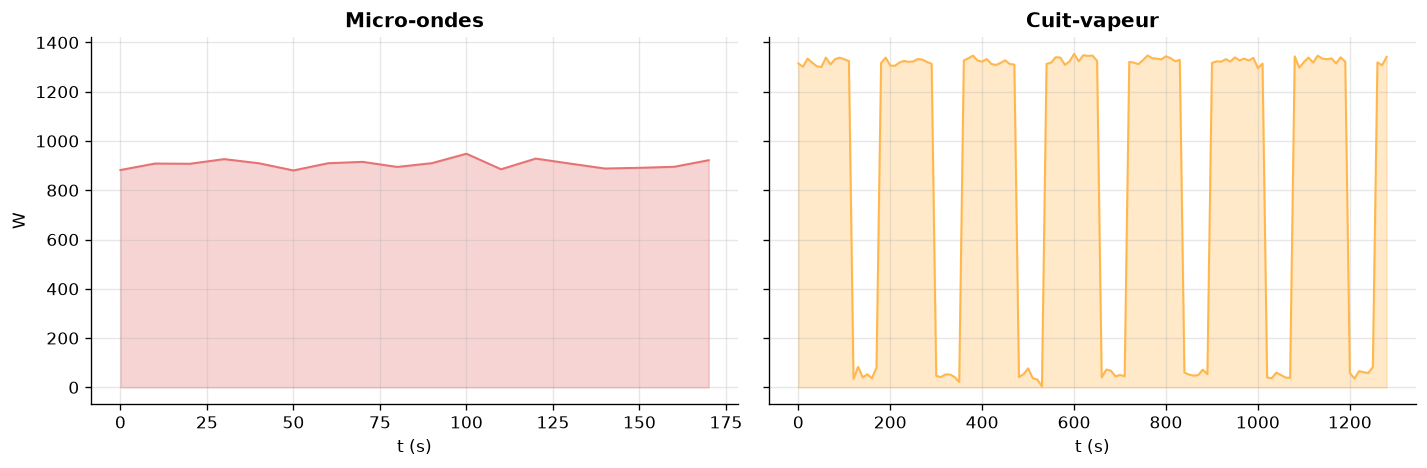

In [14]:
exemple_micro = profil_micro_ondes(seed=10)
exemple_cuit  = profil_cuit_vapeur(seed=20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
t_micro = np.arange(len(exemple_micro)) * 10
t_cuit  = np.arange(len(exemple_cuit)) * 10
axes[0].plot(t_micro, exemple_micro, color='#e57373', lw=1.2)
axes[0].fill_between(t_micro, exemple_micro, alpha=0.3, color='#e57373')
axes[0].set_title('Micro-ondes', fontweight='bold')
axes[0].set_xlabel('t (s)'); axes[0].set_ylabel('W')

axes[1].plot(t_cuit, exemple_cuit, color='#ffb74d', lw=1.2)
axes[1].fill_between(t_cuit, exemple_cuit, alpha=0.3, color='#ffb74d')
axes[1].set_title('Cuit-vapeur', fontweight='bold')
axes[1].set_xlabel('t (s)')

plt.tight_layout()
plt.show()

**Exercice** — avant de voir les moyennes affichées, calcule-les toi-même à partir de
`exemple_micro` et `exemple_cuit` (générés juste au-dessus). Stocke-les dans
`moyenne_micro` et `moyenne_cuit`.

In [15]:
# À toi de jouer : calcule la moyenne de exemple_micro et exemple_cuit
moyenne_micro = ...
moyenne_cuit = ...

In [16]:
# Cellule de test — vérifie ta réponse ci-dessus
check("moyenne_micro", moyenne_micro, exemple_micro.mean(), tol=5)
check("moyenne_cuit", moyenne_cuit, exemple_cuit.mean(), tol=5)

HTML(value="<div style='padding:8px;border-radius:6px;background:#f8d7da;color:#721c24'>❌ <b>moyenne_micro</b>…

HTML(value="<div style='padding:8px;border-radius:6px;background:#f8d7da;color:#721c24'>❌ <b>moyenne_cuit</b> …

False

In [17]:
print(f"Moyenne micro-ondes : {exemple_micro.mean():.0f} W")
print(f"Moyenne cuit-vapeur  : {exemple_cuit.mean():.0f} W")
print("Quasiment la même moyenne, alors que les formes sont visiblement très différentes.")

Moyenne micro-ondes : 906 W
Moyenne cuit-vapeur  : 910 W
Quasiment la même moyenne, alors que les formes sont visiblement très différentes.


In [18]:
qcm(
    "Micro-ondes et cuit-vapeur ont presque la même moyenne. D'après les graphiques "
    "ci-dessus, quelle caractéristique les distingue le plus clairement ?",
    [
        "Aucune, ils sont identiques dans tous les cas",
        "Le cuit-vapeur alterne entre deux niveaux de puissance (cycles ON/OFF), "
        "alors que le micro-ondes reste globalement constant",
        "Le micro-ondes dure toujours plus longtemps que le cuit-vapeur",
        "Le cuit-vapeur a une puissance moyenne beaucoup plus élevée",
    ],
    correct=1,
    explication="Le micro-ondes chauffe en continu à puissance quasi fixe. Le cuit-vapeur "
                "est piloté par un thermostat qui coupe et relance périodiquement : sa forme "
                "temporelle est cyclique, ce qui se traduit par un écart-type plus élevé et, "
                "on va le voir, un duty cycle et un spectre FFT différents."
)

![section2](pictures/cyberpunk_engraving_section2_1784108683408.png)


## 3.3 · Features avancées : FFT et duty cycle

On réutilise les outils de la Partie 2 : la **FFT** (fréquence dominante) et on
ajoute le **duty cycle** — la fraction du temps passée au-dessus du niveau *médian*
de la fenêtre. Contrairement à la Partie 1, on ne connaît pas de seuil global valable
pour tous les appareils (900 W pour le micro-ondes, 2000+ W pour le lave-linge...) :
le seuil doit donc s'adapter à chaque fenêtre.

```python
seuil = (fenetre.min() + fenetre.max()) / 2   # seuil local, pas un seuil global fixe
duty_cycle = (fenetre > seuil).mean()
```

In [19]:
def spectre_puissance(signal, dt=10):
    """FFT d'un signal 1D : renvoie (fréquences en Hz, puissance spectrale)."""
    signal  = np.asarray(signal, dtype=float)
    spectre = np.fft.rfft(signal - signal.mean())
    freqs   = np.fft.rfftfreq(len(signal), d=dt)
    return freqs, np.abs(spectre) ** 2

def periode_dominante_min(signal, dt=10):
    """Période (en minutes) du pic dominant du spectre de puissance."""
    freqs, p = spectre_puissance(signal, dt)
    if len(p) < 2:
        return 0.0
    idx = np.argmax(p[1:]) + 1
    return 1 / freqs[idx] / 60 if freqs[idx] > 0 else 0.0

def duty_cycle(v, seuil=None):
    """Fraction du temps au-dessus d'un seuil local (milieu min/max de la fenêtre)."""
    v = np.asarray(v, dtype=float)
    if seuil is None:
        seuil = (v.min() + v.max()) / 2
    return (v > seuil).mean()

print(f"Duty cycle micro-ondes : {duty_cycle(exemple_micro):.0%}")
print(f"Duty cycle cuit-vapeur : {duty_cycle(exemple_cuit):.0%}")

Duty cycle micro-ondes : 28%
Duty cycle cuit-vapeur : 67%


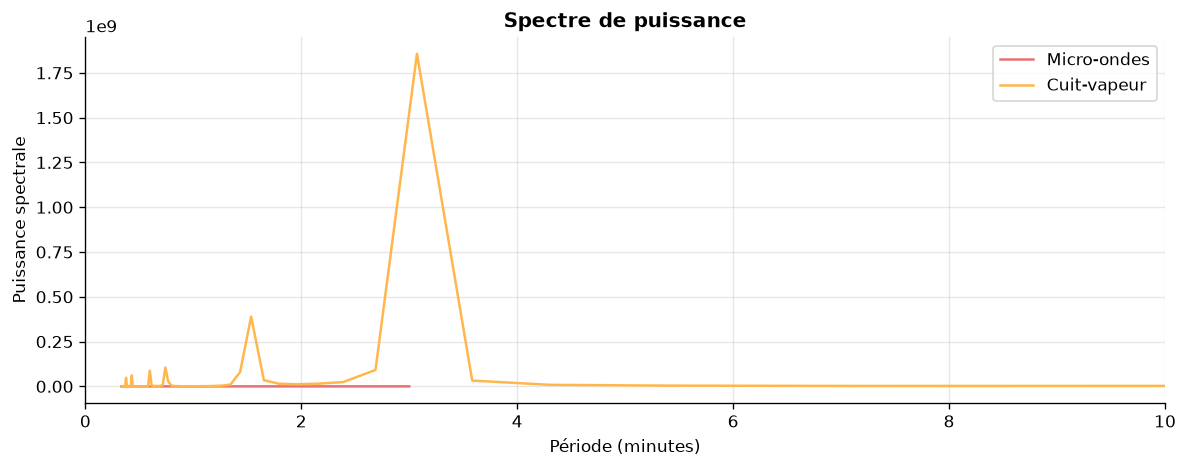

Le cuit-vapeur a un pic net (son cycle ON/OFF), le micro-ondes n'a pas de rythme marqué.


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
for sig, nom, coul in [(exemple_micro, 'Micro-ondes', '#e57373'), (exemple_cuit, 'Cuit-vapeur', '#ffb74d')]:
    freqs, p = spectre_puissance(sig)
    periode = 1 / freqs[1:] / 60
    ax.plot(periode, p[1:], color=coul, label=nom)
ax.set_xlim(0, 10)
ax.set_xlabel('Période (minutes)')
ax.set_ylabel('Puissance spectrale')
ax.set_title('Spectre de puissance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Le cuit-vapeur a un pic net (son cycle ON/OFF), le micro-ondes n'a pas de rythme marqué.")

**Exercice** — calcule le duty cycle d'un **nouvel** exemple de cuit-vapeur
(`exemple_cuit2`, généré ci-dessous avec un autre seed) et stocke-le dans `duty_cuit2`.

In [21]:
exemple_cuit2 = profil_cuit_vapeur(seed=21)

# À toi de jouer : calcule le duty cycle de exemple_cuit2 (utilise duty_cycle())
duty_cuit2 = ...

In [22]:
# Cellule de test — vérifie ta réponse ci-dessus
check("duty_cuit2", duty_cuit2, duty_cycle(exemple_cuit2), tol=0.05)

HTML(value="<div style='padding:8px;border-radius:6px;background:#f8d7da;color:#721c24'>❌ <b>duty_cuit2</b> in…

False

In [23]:
qcm(
    "Le duty cycle du cuit-vapeur (~67%, cycle 120s ON / 60s OFF) est nettement "
    "inférieur à celui du micro-ondes (~100%, toujours ON). Pourquoi le seuil utilisé "
    "ici est-il calculé comme `(min + max) / 2` plutôt qu'une valeur fixe comme 90 W "
    "(la Partie 1) ?",
    [
        "Parce que 90 W est une valeur arbitraire sans rapport avec les nouveaux appareils",
        "Un seuil fixe à 90 W classerait presque tout comme 'ON' pour des appareils "
        "qui consomment 900-2500 W : il faut un seuil qui s'adapte au niveau de chaque fenêtre",
        "Le seuil (min+max)/2 est toujours égal à 90 W en pratique",
        "Ça n'a pas d'importance, les deux seuils donnent le même résultat",
    ],
    correct=1,
    explication="Le seuil de 90 W de la Partie 1 était calibré pour le frigo (30-150 W). "
                "Pour un micro-ondes à 900 W ou un lave-linge à 2500 W, ce seuil est ridiculement "
                "bas — tout serait 'ON'. Un seuil local, recalculé pour chaque fenêtre à partir "
                "de son propre min et max, s'adapte automatiquement au niveau de l'appareil observé."
)

## 3.4 · Construire un jeu de données de features

Pour entraîner un classifieur, une seule occurrence de chaque appareil ne suffit pas :
il faut **plusieurs exemples** par classe, avec de la variabilité (durée, bruit) —
comme si le détecteur de fronts de la section 3.1 en avait trouvé plusieurs occurrences
sur plusieurs jours. On génère 12 instances de chaque appareil et on calcule, pour
chacune, le vecteur de features : durée, moyenne, écart-type, duty cycle, période FFT.

In [24]:
N_PAR_CLASSE = 12

GENERATEURS = {
    'micro_ondes': (profil_micro_ondes, 300),
    'cuit_vapeur':  (profil_cuit_vapeur, 500),
    'lave_linge':   (profil_lave_linge, 700),
}

def extraire_features(v, dt=10):
    v = np.asarray(v, dtype=float)
    return {
        'duree_s':     len(v) * dt,
        'moyenne':     v.mean(),
        'ecart_type':  v.std(),
        'duty_cycle':  duty_cycle(v),
        'periode_min': periode_dominante_min(v, dt),
    }

lignes = []
fenetres_dataset = []   # on garde aussi les signaux bruts pour la Partie 3.6 (DTW)
rng_baseline = random.Random(999)

for classe, (gen, base_seed) in GENERATEURS.items():
    for k in range(N_PAR_CLASSE):
        v = gen(seed=base_seed + k)
        v = v + rng_baseline.choice([30, 150])   # le frigo continue de tourner en fond
        feats = extraire_features(v)
        feats['classe'] = classe
        lignes.append(feats)
        fenetres_dataset.append({'classe': classe, 'values': v})

df_events = pd.DataFrame(lignes)
print(f"{len(df_events)} évènements ({N_PAR_CLASSE} par classe)")
print(df_events.groupby('classe')[['duree_s', 'moyenne', 'ecart_type', 'duty_cycle', 'periode_min']].mean().round(1).to_string())

36 évènements (12 par classe)
             duree_s  moyenne  ecart_type  duty_cycle  periode_min
classe                                                            
cuit_vapeur   1196.7    990.4       593.3         0.7          3.0
lave_linge     885.8   1419.4       951.5         0.5         14.8
micro_ondes    171.7    989.4        14.5         0.5          1.0


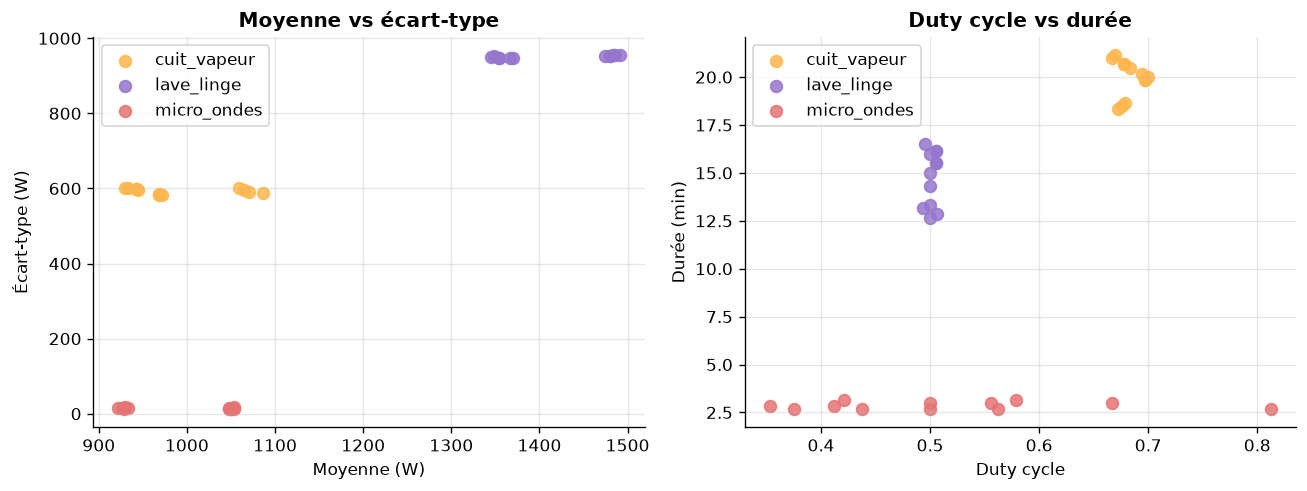

Aucune paire de features ne sépare parfaitement les 3 classes à elle seule —
c'est pour ça qu'on va donner TOUT le vecteur de features à un classifieur.


In [25]:
couleurs3 = {'micro_ondes': '#e57373', 'cuit_vapeur': '#ffb74d', 'lave_linge': '#9575cd'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for classe, grp in df_events.groupby('classe'):
    axes[0].scatter(grp['moyenne'], grp['ecart_type'], c=couleurs3[classe], label=classe, s=50, alpha=0.85)
axes[0].set_xlabel('Moyenne (W)')
axes[0].set_ylabel('Écart-type (W)')
axes[0].set_title('Moyenne vs écart-type', fontweight='bold')
axes[0].legend()

for classe, grp in df_events.groupby('classe'):
    axes[1].scatter(grp['duty_cycle'], grp['duree_s'] / 60, c=couleurs3[classe], label=classe, s=50, alpha=0.85)
axes[1].set_xlabel('Duty cycle')
axes[1].set_ylabel('Durée (min)')
axes[1].set_title('Duty cycle vs durée', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Aucune paire de features ne sépare parfaitement les 3 classes à elle seule —")
print("c'est pour ça qu'on va donner TOUT le vecteur de features à un classifieur.")

In [26]:
qcm(
    "Pourquoi génère-t-on 12 instances de chaque appareil plutôt qu'une seule ?",
    [
        "Pour que le notebook prenne plus de temps à s'exécuter",
        "Un classifieur a besoin de plusieurs exemples par classe pour apprendre "
        "la variabilité naturelle (bruit, durée) et pour qu'on puisse évaluer "
        "sa performance par validation croisée",
        "windowing.slice_on_edges exige au moins 12 fenêtres pour fonctionner",
        "Une seule instance suffit largement, 12 est arbitraire",
    ],
    correct=1,
    explication="Avec un seul exemple par classe, un modèle ne peut ni apprendre la variabilité "
                "réelle (durée, bruit, amplitude qui changent d'un jour à l'autre) ni être évalué "
                "correctement : la validation croisée a besoin de plusieurs exemples par classe "
                "pour séparer données d'entraînement et de test de façon significative."
)

## 3.5 · Random Forest

Un **Random Forest** est un ensemble d'arbres de décision entraînés sur des sous-échantillons
aléatoires des données ; leur vote majoritaire donne la prédiction finale. On l'entraîne sur
le vecteur de features de la section 3.4, et on l'évalue avec une validation croisée
5-fold (chaque exemple sert de test exactement une fois, sur un modèle qui ne l'a jamais vu
à l'entraînement).

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score

FEATURES = ['duree_s', 'moyenne', 'ecart_type', 'duty_cycle', 'periode_min']
X = df_events[FEATURES].to_numpy()
y = df_events['classe'].to_numpy()
classes = sorted(df_events['classe'].unique())

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
rf = RandomForestClassifier(n_estimators=200, random_state=0)
y_pred_rf = cross_val_predict(rf, X, y, cv=folds)

cm_rf = confusion_matrix(y, y_pred_rf, labels=classes)
acc_rf = accuracy_score(y, y_pred_rf)
print(f"Random Forest — accuracy (validation croisée 5-fold) : {acc_rf:.0%}")

Random Forest — accuracy (validation croisée 5-fold) : 100%


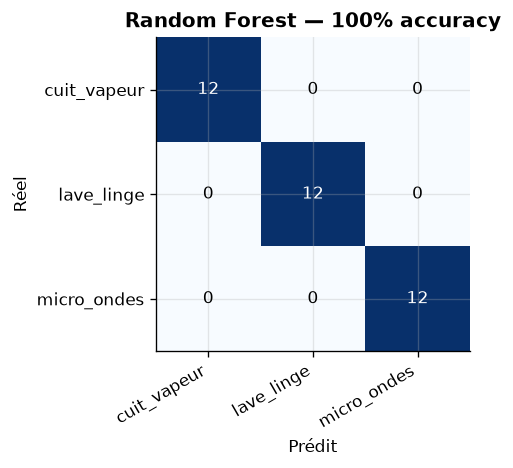

In [28]:
def tracer_matrice_confusion(cm, classes, titre):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=30, ha='right')
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
    ax.set_title(titre, fontweight='bold')
    for i in range(len(classes)):
        for j in range(len(classes)):
            couleur = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=couleur)
    plt.tight_layout()
    plt.show()

tracer_matrice_confusion(cm_rf, classes, f'Random Forest — {acc_rf:.0%} accuracy')

**Exercice** — sans utiliser `accuracy_score`, calcule l'accuracy toi-même à partir de
`cm_rf` : la diagonale contient les prédictions correctes, la somme totale contient tous
les évènements. Stocke le résultat dans `mon_accuracy`.

In [29]:
# À toi de jouer : calcule l'accuracy à partir de cm_rf (diagonale / somme totale)
mon_accuracy = ...

In [30]:
# Cellule de test — vérifie ta réponse ci-dessus
check("mon_accuracy", mon_accuracy, acc_rf, tol=1e-6)

HTML(value="<div style='padding:8px;border-radius:6px;background:#f8d7da;color:#721c24'>❌ <b>mon_accuracy</b> …

False

In [31]:
qcm(
    "Sur la matrice de confusion, une valeur hors de la diagonale (ex: ligne "
    "'cuit_vapeur', colonne 'micro_ondes') signifie quoi ?",
    [
        "Le modèle a raté cet exemple : il était réellement 'cuit_vapeur' "
        "mais prédit comme 'micro_ondes'",
        "Il y a une erreur dans le code, cette case devrait toujours être à 0",
        "Le modèle a bien classé cet exemple",
        "Cette case indique le nombre total d'exemples de cuit-vapeur",
    ],
    correct=0,
    explication="Dans une matrice de confusion, les lignes sont la vraie classe et les colonnes "
                "la classe prédite. Une valeur hors diagonale (ligne ≠ colonne) est une erreur de "
                "classification : ici, un cuit-vapeur confondu avec un micro-ondes."
)

## 3.6 · DTW — comparer les formes directement

Le **DTW** (Dynamic Time Warping) ne calcule aucune feature : il compare deux signaux
bruts point par point, en autorisant de petits décalages temporels (utile quand la
durée d'un cycle varie légèrement d'un exemple à l'autre). On l'utilise ici en
**1-plus-proche-voisin** : chaque évènement est classé comme son voisin le plus
proche (au sens DTW) parmi les exemples d'entraînement.

Le calcul de DTW coûte cher (comparaison de toutes les paires de points) : on
sous-échantillonne les fenêtres longues (un point sur 3) juste avant de calculer les
distances — un compromis vitesse/précision courant en pratique.

DTW 1-NN — accuracy (mêmes folds que le Random Forest) : 100%


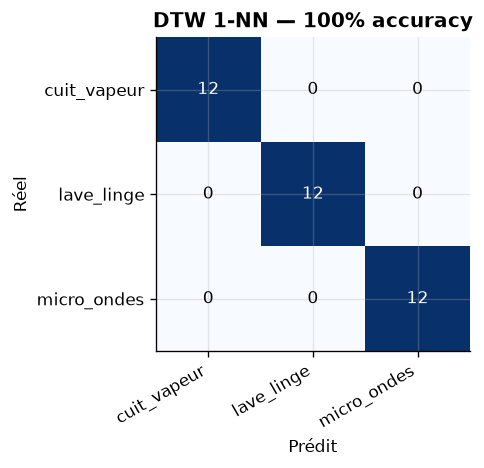

In [32]:
def dtw_distance(a, b):
    """Distance DTW classique (programmation dynamique, coût = écart absolu)."""
    n, m = len(a), len(b)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        ai = a[i - 1]
        for j in range(1, m + 1):
            cout = abs(ai - b[j - 1])
            D[i, j] = cout + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return D[n, m]

# Sous-échantillonnage (1 point sur 3) pour garder le calcul rapide
signaux_dtw = [f['values'][::3] for f in fenetres_dataset]
classes_dtw = np.array([f['classe'] for f in fenetres_dataset])

y_pred_dtw = np.empty(len(signaux_dtw), dtype=object)

for tr_idx, te_idx in folds.split(X, y):
    for i in te_idx:
        distances = [dtw_distance(signaux_dtw[i], signaux_dtw[j]) for j in tr_idx]
        plus_proche = tr_idx[np.argmin(distances)]
        y_pred_dtw[i] = classes_dtw[plus_proche]

cm_dtw = confusion_matrix(classes_dtw, y_pred_dtw, labels=classes)
acc_dtw = accuracy_score(classes_dtw, y_pred_dtw)
print(f"DTW 1-NN — accuracy (mêmes folds que le Random Forest) : {acc_dtw:.0%}")

tracer_matrice_confusion(cm_dtw, classes, f'DTW 1-NN — {acc_dtw:.0%} accuracy')

In [33]:
print(f"Random Forest : {acc_rf:.0%}")
print(f"DTW 1-NN      : {acc_dtw:.0%}")

Random Forest : 100%
DTW 1-NN      : 100%


In [34]:
qcm(
    "Le Random Forest a besoin d'un vecteur de features de taille fixe (5 nombres). "
    "Le DTW travaille directement sur les signaux bruts, de longueur variable. "
    "Quel est l'avantage principal du DTW dans ce contexte ?",
    [
        "Le DTW est toujours plus précis que n'importe quel classifieur à features",
        "Le DTW ne nécessite aucune étape d'ingénierie de features : pas besoin de "
        "choisir/calculer moyenne, duty cycle, FFT... il compare les formes directement",
        "Le DTW est toujours plus rapide à calculer que le Random Forest",
        "Le DTW peut fonctionner sans aucun exemple d'entraînement",
    ],
    correct=1,
    explication="Le DTW s'affranchit du choix des features : il compare la forme brute des "
                "signaux, tolère les décalages temporels, et n'a besoin d'aucune étape "
                "d'extraction préalable. Le prix à payer est le coût de calcul (comparaison "
                "de toutes les paires) et le besoin de garder des exemples d'entraînement en mémoire."
)

In [35]:
qcm(
    "Pourquoi sous-échantillonne-t-on les signaux (un point sur 3) avant de "
    "calculer le DTW, alors qu'on garde la résolution complète pour les features "
    "de la Partie 3.4 ?",
    [
        "Le DTW ne fonctionne pas sur des signaux à haute résolution",
        "Le coût de calcul du DTW croît avec le produit des longueurs des deux "
        "signaux comparés : sous-échantillonner réduit ce coût sans changer la "
        "forme générale du signal",
        "Sous-échantillonner améliore toujours la précision du DTW",
        "C'est nécessaire pour que les deux signaux aient la même longueur",
    ],
    correct=1,
    explication="La programmation dynamique du DTW remplit une grille de taille n×m : diviser "
                "les longueurs par 3 divise le coût par ~9. La forme générale du signal (phases "
                "du lave-linge, cycles du cuit-vapeur) reste identifiable même en gardant 1 point "
                "sur 3, contrairement à une réduction beaucoup plus agressive."
)

---
## Récapitulatif

| Méthode | Entrée | Features à choisir ? | Points forts |
|---------|--------|----------------------|-------------|
| Random Forest | Vecteur de features (durée, stats, FFT, duty cycle) | Oui | Rapide à l'entraînement et à la prédiction, interprétable (importance des features) |
| DTW 1-NN | Signal brut, longueur variable | Non | Tolère les décalages temporels, pas d'ingénierie de features, mais coûteux en calcul |

Sur les trois parties de ce notebook, on est parti d'un seul appareil et deux features
(moyenne, écart-type) pour arriver à plusieurs appareils, plusieurs familles de
features (stats, FFT, ondelettes, duty cycle) et deux méthodes de classification
complètes, validées par validation croisée.

**Prochaine étape** : utiliser les vraies données du compteur Linky, avec `data_sync.py`,
et voir si ces méthodes tiennent la route sur un signal réel — plus bruité et moins
parfaitement périodique que nos simulations.